Balanced dataset shape: (5000, 35)
Accuracy: 0.777
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       500
           1       0.80      0.74      0.77       500

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000



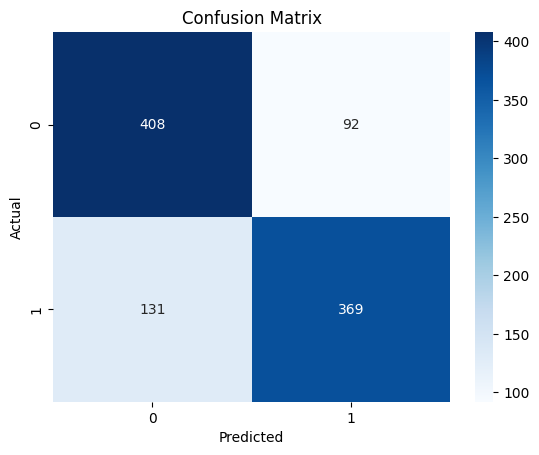

Random Forest Accuracy: 0.931
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       500
           1       0.90      0.97      0.93       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



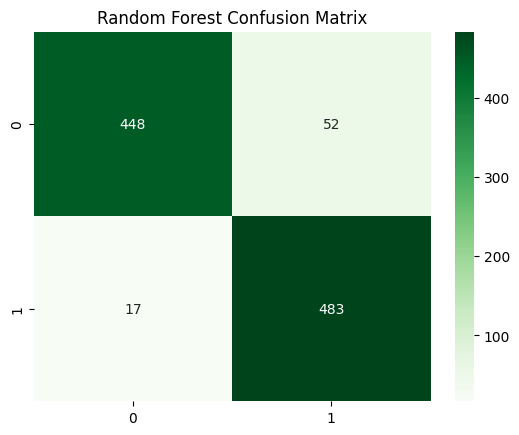

statuses_count                  0.185238
favourites_count                0.167111
followers_count                 0.135281
utc_offset                      0.110687
listed_count                    0.070089
geo_enabled                     0.068841
default_profile                 0.063374
friends_count                   0.058747
id                              0.052261
profile_use_background_image    0.043146
profile_background_tile         0.042973
default_profile_image           0.002250
protected                       0.000000
verified                        0.000000
dtype: float64
XGBoost Accuracy: 0.93
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       500
           1       0.90      0.97      0.93       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



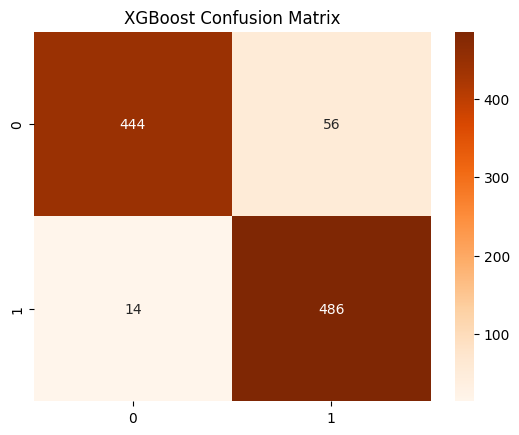

c:\Users\Induk\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


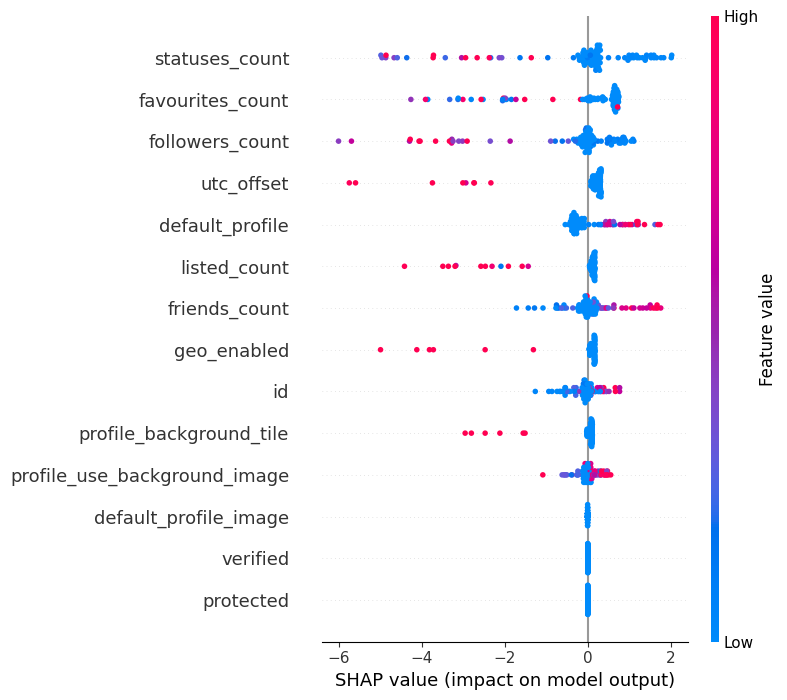

c:\Users\Induk\AppData\Local\Programs\Python\Python311\python.exe


['../backend/detectx_features.pkl']

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
# Load synthetic dataset
synthetic_df = pd.read_csv("../data/fake_social_media/fake_social_media.csv")

# Load real-world datasets
fake_df = pd.read_csv("../data/fake_social_media/fake_users.csv")
real_df = pd.read_csv("../data/fake_social_media/real_users.csv")
# Add labels
fake_df['is_fake'] = 1
real_df['is_fake'] = 0

# Combine
df_balanced = pd.concat([fake_df, real_df], ignore_index=True)

print("Balanced dataset shape:", df_balanced.shape)
df_balanced['is_fake'].value_counts()
missing = df_balanced.isnull().sum()
missing[missing > 0]
drop_cols = [
    'name', 'screen_name', 'created_at', 'url', 'lang', 'time_zone',
    'location', 'profile_image_url', 'profile_banner_url',
    'profile_background_image_url_https', 'profile_text_color',
    'profile_image_url_https', 'profile_sidebar_border_color',
    'profile_sidebar_fill_color', 'profile_background_image_url',
    'profile_background_color', 'profile_link_color', 'description',
    'updated', 'dataset'
]

df_balanced = df_balanced.drop(columns=drop_cols)
df_balanced.isnull().sum()
df_balanced.columns
df_balanced = pd.get_dummies(df_balanced, drop_first=True)
X = df_balanced.drop('is_fake', axis=1)
y = df_balanced['is_fake']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(15))
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))
cm_xgb = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost Confusion Matrix")
plt.show()
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb)

# Select sample data
sample = X_test.iloc[:100]

# Get SHAP values
shap_values = explainer.shap_values(sample)

# Plot
shap.summary_plot(shap_values, sample)
import sys
print(sys.executable)
import joblib
joblib.dump(xgb, "../backend/detectx_model.pkl")
joblib.dump(X.columns, "../backend/detectx_features.pkl")

In [2]:
%pip install -U joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
